In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)


In [7]:
url = "https://raw.githubusercontent.com/datasets/covid-19/main/data/countries-aggregated.csv"

df = pd.read_csv(url)
df["Date"] = pd.to_datetime(df["Date"])

print("Dataset Shape :", df.shape)
df.head()

Dataset Shape : (161568, 5)


,Date,Country,Confirmed,Recovered,Deaths
0,2020-01-22,Afghanistan,0,0,0
1,2020-01-23,Afghanistan,0,0,0
2,2020-01-24,Afghanistan,0,0,0
3,2020-01-25,Afghanistan,0,0,0
4,2020-01-26,Afghanistan,0,0,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161568 entries, 0 to 161567
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Date       161568 non-null  datetime64[us]
 1   Country    161568 non-null  str           
 2   Confirmed  161568 non-null  int64         
 3   Recovered  161568 non-null  int64         
 4   Deaths     161568 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 7.5 MB


In [9]:
print("Missing Values")
display(df.isnull().sum())

Missing Values


Date         0
Country      0
Confirmed    0
Recovered    0
Deaths       0
dtype: int64

In [19]:
# Create Daily Metrics

In [10]:
df["New_Cases"] = df.groupby("Country")["Confirmed"].diff().fillna(0)
df["New_Deaths"] = df.groupby("Country")["Deaths"].diff().fillna(0)
df["New_Recovered"] = df.groupby("Country")["Recovered"].diff().fillna(0)

df.head()

,Date,Country,Confirmed,Recovered,Deaths,New_Cases,New_Deaths,New_Recovered
0,2020-01-22,Afghanistan,0,0,0,0.0,0.0,0.0
1,2020-01-23,Afghanistan,0,0,0,0.0,0.0,0.0
2,2020-01-24,Afghanistan,0,0,0,0.0,0.0,0.0
3,2020-01-25,Afghanistan,0,0,0,0.0,0.0,0.0
4,2020-01-26,Afghanistan,0,0,0,0.0,0.0,0.0


In [11]:
india = df[df["Country"]=="India"].copy()

print("India Dataset Shape :", india.shape)
india.head()

India Dataset Shape : (816, 8)


,Date,Country,Confirmed,Recovered,Deaths,New_Cases,New_Deaths,New_Recovered
65280,2020-01-22,India,0,0,0,0.0,0.0,0.0
65281,2020-01-23,India,0,0,0,0.0,0.0,0.0
65282,2020-01-24,India,0,0,0,0.0,0.0,0.0
65283,2020-01-25,India,0,0,0,0.0,0.0,0.0
65284,2020-01-26,India,0,0,0,0.0,0.0,0.0


In [20]:
# Confirmed Cases Trend

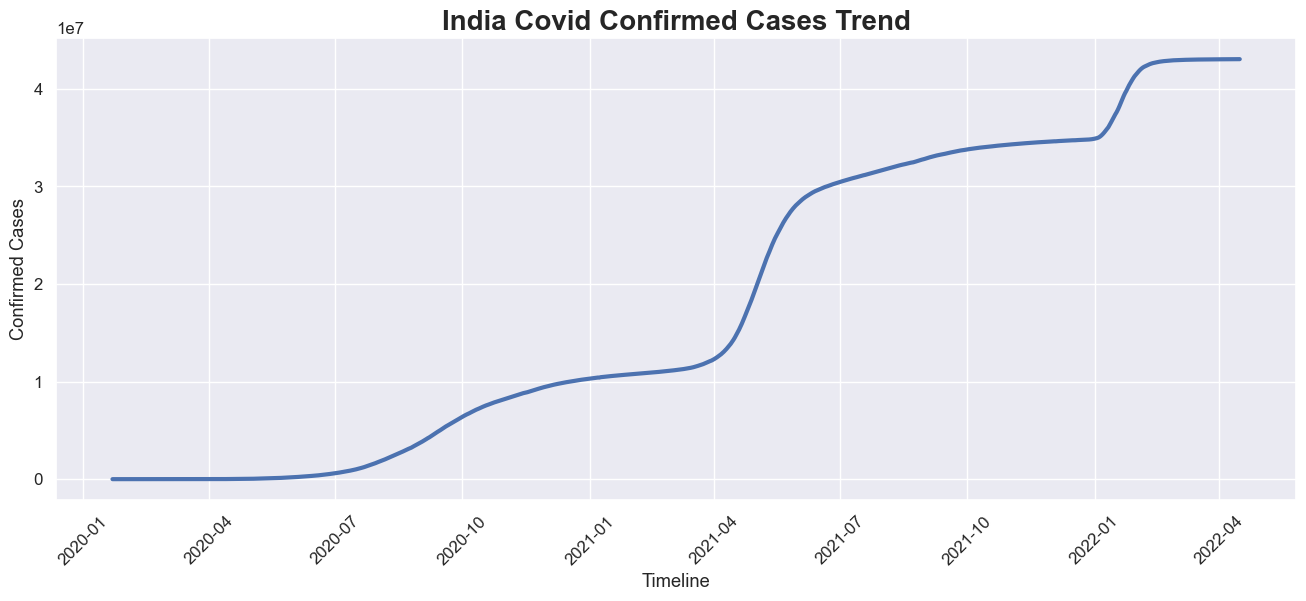

In [12]:
plt.figure(figsize=(16,6))

plt.plot(
    india["Date"],
    india["Confirmed"],
    linewidth=3
)

plt.title("India Covid Confirmed Cases Trend", fontsize=20, weight="bold")
plt.xlabel("Timeline")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)

plt.show()

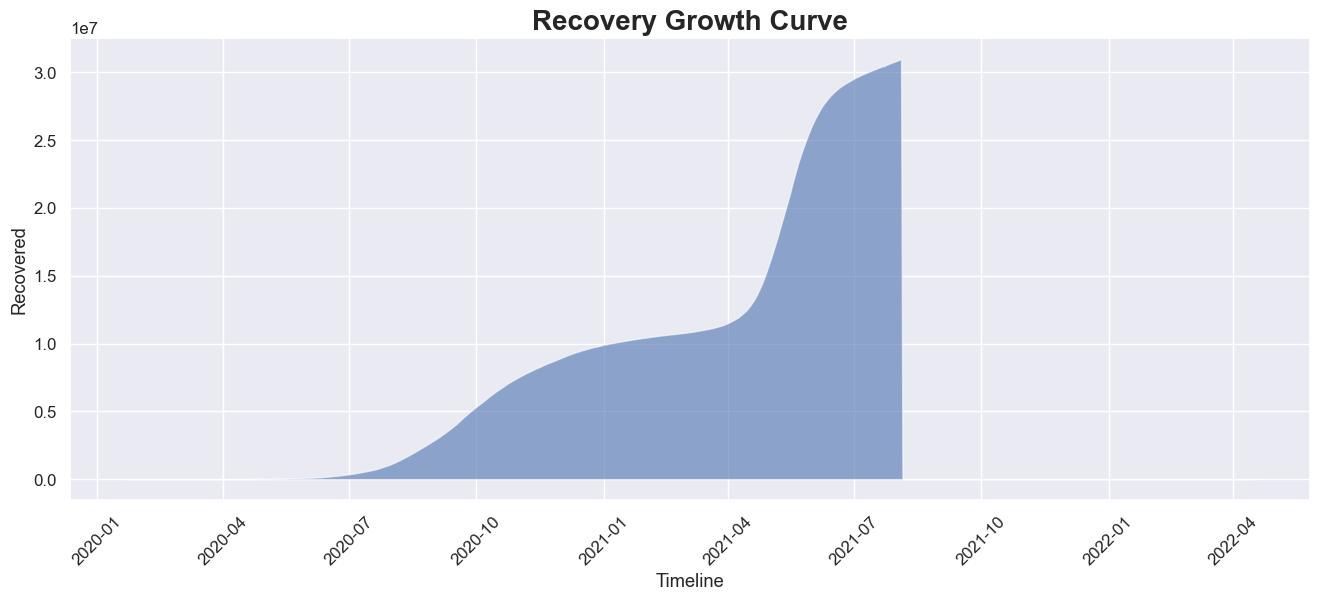

In [13]:
plt.figure(figsize=(16,6))

plt.fill_between(
    india["Date"],
    india["Recovered"],
    alpha=0.6
)

plt.title("Recovery Growth Curve", fontsize=20, weight="bold")
plt.xlabel("Timeline")
plt.ylabel("Recovered")

plt.xticks(rotation=45)
plt.show()

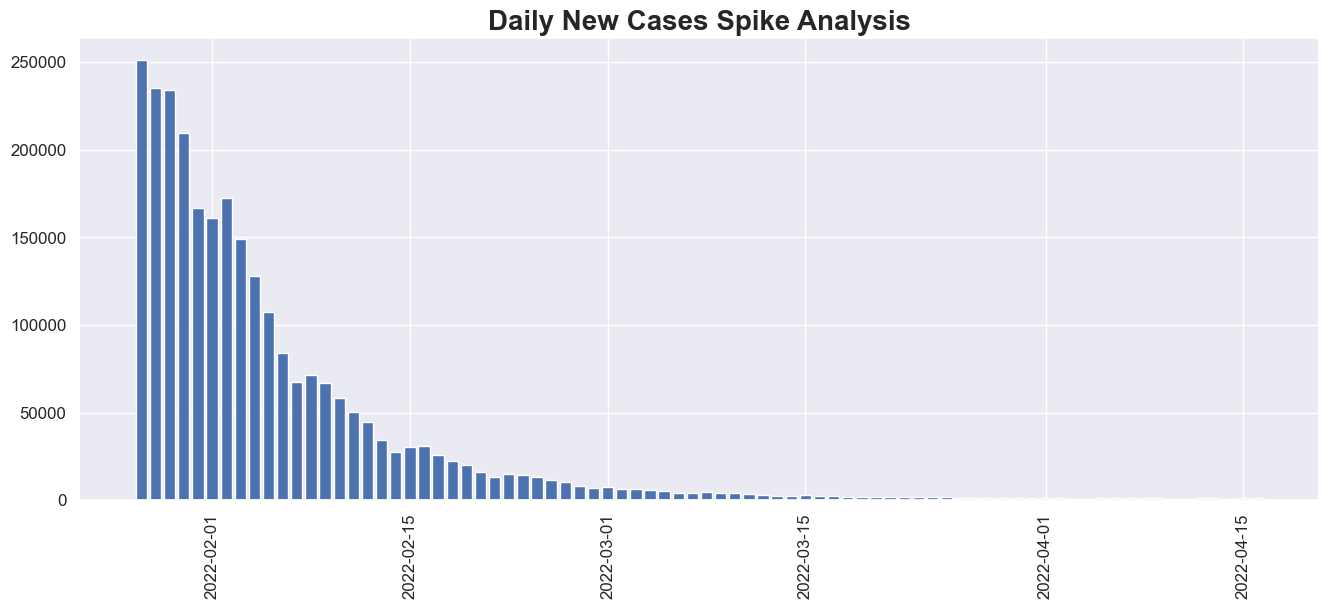

In [14]:
plt.figure(figsize=(16,6))

plt.bar(
    india["Date"].tail(80),
    india["New_Cases"].tail(80)
)

plt.title("Daily New Cases Spike Analysis", fontsize=20, weight="bold")
plt.xticks(rotation=90)

plt.show()

In [21]:
# Top Countries Comparison

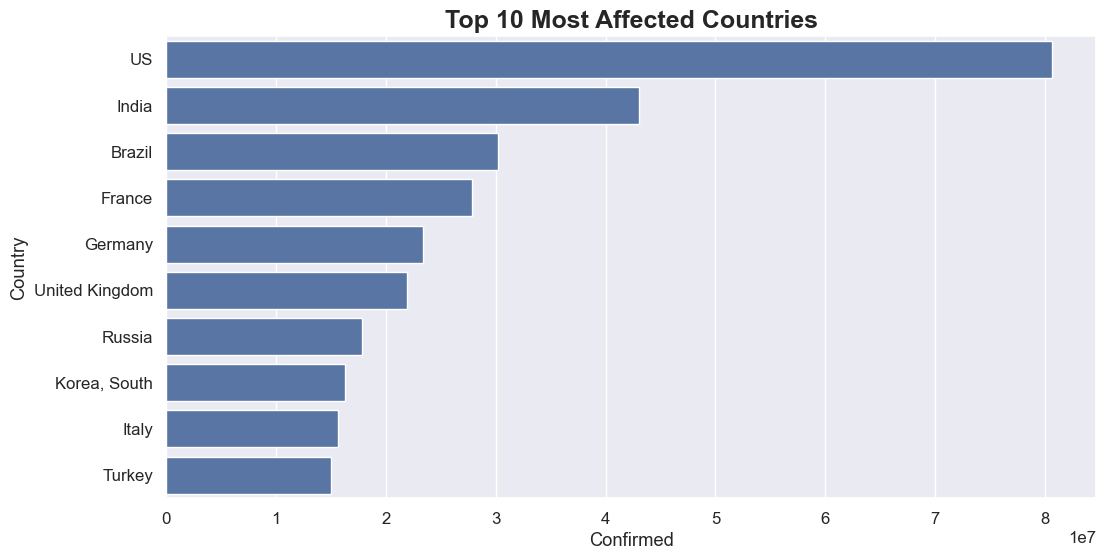

In [15]:
latest = df[df["Date"]==df["Date"].max()]

top = latest.sort_values(
    "Confirmed",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x="Confirmed",
    y="Country",
    data=top
)

plt.title("Top 10 Most Affected Countries", fontsize=18, weight="bold")
plt.show()

In [16]:
india["Death_Rate"] = (
    india["Deaths"] / india["Confirmed"]
) * 100

india["Recovery_Rate"] = (
    india["Recovered"] / india["Confirmed"]
) * 100

india[["Death_Rate","Recovery_Rate"]].tail()

,Death_Rate,Recovery_Rate
66091,1.212268,0.0
66092,1.212242,0.0
66093,1.212229,0.0
66094,1.212211,0.0
66095,1.212188,0.0


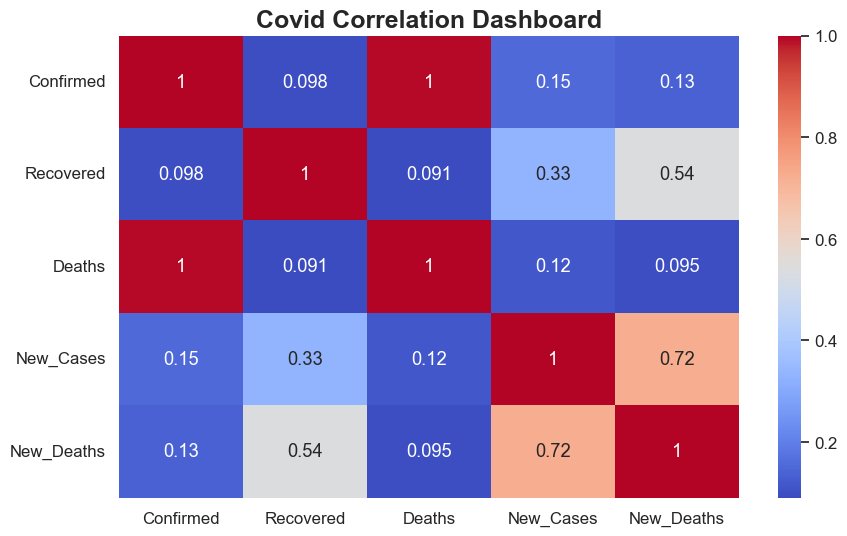

In [17]:
plt.figure(figsize=(10,6))

sns.heatmap(
    india[
        ["Confirmed","Recovered","Deaths","New_Cases","New_Deaths"]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Covid Correlation Dashboard", fontsize=18, weight="bold")
plt.show()

In [18]:
summary = pd.DataFrame({
    "Metric":[
        "Total Confirmed",
        "Total Recovered",
        "Total Deaths"
    ],
    "Value":[
        india["Confirmed"].max(),
        india["Recovered"].max(),
        india["Deaths"].max()
    ]
})

summary

,Metric,Value
0,Total Confirmed,43042097
1,Total Recovered,30974748
2,Total Deaths,521751
